# ClinVar Data Acquisition and Profiling

## Project

Mapping the Genetic Landscape of Human Disease with Apache Spark

## Objective

This notebook performs:

1. Download of ClinVar public data
2. Extraction of source files
3. Creation of development samples
4. Initial data profiling
5. Data quality assessment
6. Curated schema design

The output of this notebook will be used by downstream Spark ETL pipelines.

In [14]:
from pathlib import Path

folders = [
    "../data/raw",
    "../data/sample",
    "../data/processed"
]

for folder in folders:
    Path(folder).mkdir(
        parents=True,
        exist_ok=True
    )

print("Directories created")

Directories created


### Download ClinVar Dataset

In [15]:
import requests

url = (
    "https://ftp.ncbi.nlm.nih.gov/"
    "pub/clinvar/tab_delimited/"
    "variant_summary.txt.gz"
)

output_file = "../data/raw/variant_summary.txt.gz"

response = requests.get(
    url,
    stream=True
)

with open(output_file, "wb") as f:
    for chunk in response.iter_content(
        chunk_size=8192
    ):
        f.write(chunk)

print("Download complete")

Download complete


### Verify Download

In [16]:
from pathlib import Path

file_path = Path(
    "../data/raw/variant_summary.txt.gz"
)

print(
    f"Size: {file_path.stat().st_size / 1024 / 1024:.2f} MB"
)

Size: 418.84 MB


## Extract Dataset

In [17]:
import gzip
import shutil

source = "../data/raw/variant_summary.txt.gz"
target = "../data/raw/variant_summary.txt"

with gzip.open(source, "rb") as f_in:
    with open(target, "wb") as f_out:
        shutil.copyfileobj(
            f_in,
            f_out
        )

print("Extraction complete")

Extraction complete


### Verify File Exists

In [18]:
from pathlib import Path

file_path = Path(
    "../data/raw/variant_summary.txt"
)

print(file_path.exists())

True


### Create Development Sample

In [19]:
import pandas as pd

sample_size = 50000

df_sample = pd.read_csv(
    "../data/raw/variant_summary.txt",
    sep="\t",
    nrows=sample_size,
    low_memory=False
)

sample_file = (
    "../data/sample/"
    "variant_summary_sample.txt"
)

df_sample.to_csv(
    sample_file,
    sep="\t",
    index=False
)

print(
    f"Sample file created with "
    f"{sample_size:,} rows"
)

Sample file created with 50,000 rows


### Load Sample Dataset

In [20]:
import pandas as pd

df = pd.read_csv(
    "../data/sample/variant_summary_sample.txt",
    sep="\t",
    low_memory=False
)

print(df.shape)

(50000, 43)


### Inspect Columns

In [21]:
df.columns.tolist()

['#AlleleID',
 'Type',
 'Name',
 'GeneID',
 'GeneSymbol',
 'HGNC_ID',
 'ClinicalSignificance',
 'ClinSigSimple',
 'LastEvaluated',
 'RS# (dbSNP)',
 'nsv/esv (dbVar)',
 'RCVaccession',
 'PhenotypeIDS',
 'PhenotypeList',
 'Origin',
 'OriginSimple',
 'Assembly',
 'ChromosomeAccession',
 'Chromosome',
 'Start',
 'Stop',
 'ReferenceAllele',
 'AlternateAllele',
 'Cytogenetic',
 'ReviewStatus',
 'NumberSubmitters',
 'Guidelines',
 'TestedInGTR',
 'OtherIDs',
 'SubmitterCategories',
 'VariationID',
 'PositionVCF',
 'ReferenceAlleleVCF',
 'AlternateAlleleVCF',
 'SomaticClinicalImpact',
 'SomaticClinicalImpactLastEvaluated',
 'ReviewStatusClinicalImpact',
 'Oncogenicity',
 'OncogenicityLastEvaluated',
 'ReviewStatusOncogenicity',
 'SCVsForAggregateGermlineClassification',
 'SCVsForAggregateSomaticClinicalImpact',
 'SCVsForAggregateOncogenicityClassification']

### Preview Records

In [22]:
df.head()

,#AlleleID,Type,Name,GeneID,GeneSymbol,HGNC_ID,ClinicalSignificance,ClinSigSimple,LastEvaluated,RS# (dbSNP),...,AlternateAlleleVCF,SomaticClinicalImpact,SomaticClinicalImpactLastEvaluated,ReviewStatusClinicalImpact,Oncogenicity,OncogenicityLastEvaluated,ReviewStatusOncogenicity,SCVsForAggregateGermlineClassification,SCVsForAggregateSomaticClinicalImpact,SCVsForAggregateOncogenicityClassification
0,15041,Indel,NM_014855.3(AP5Z1):c.80_83delinsTGCTGTAAACTGTA...,9907,AP5Z1,HGNC:22197,Pathogenic/Likely pathogenic,1,"Dec 17, 2024",397704705,...,TGCTGTAAACTGTAACTGTAAA,-,-,-,-,-,-,SCV001451119|SCV005622007|SCV005909190,-,-
1,15041,Indel,NM_014855.3(AP5Z1):c.80_83delinsTGCTGTAAACTGTA...,9907,AP5Z1,HGNC:22197,Pathogenic/Likely pathogenic,1,"Dec 17, 2024",397704705,...,TGCTGTAAACTGTAACTGTAAA,-,-,-,-,-,-,SCV001451119|SCV005622007|SCV005909190,-,-
2,15042,Deletion,NM_014855.3(AP5Z1):c.1413_1426del (p.Leu473fs),9907,AP5Z1,HGNC:22197,Pathogenic,1,"Jun 29, 2010",397704709,...,G,-,-,-,-,-,-,SCV000020156,-,-
3,15042,Deletion,NM_014855.3(AP5Z1):c.1413_1426del (p.Leu473fs),9907,AP5Z1,HGNC:22197,Pathogenic,1,"Jun 29, 2010",397704709,...,G,-,-,-,-,-,-,SCV000020156,-,-
4,15043,single nucleotide variant,NM_014630.3(ZNF592):c.3136G>A (p.Gly1046Arg),9640,ZNF592,HGNC:28986,Uncertain significance,0,"Jun 29, 2015",150829393,...,A,-,-,-,-,-,-,SCV000020157,-,-


###  Data Volume

In [23]:
print(
    f"Rows: {df.shape[0]:,}"
)

print(
    f"Columns: {df.shape[1]}"
)

Rows: 50,000
Columns: 43


###  Missing Value Analysis

In [24]:
missing = (
    df.isnull()
      .sum()
      .sort_values(
          ascending=False
      )
)

missing.head(20)

#AlleleID                                 0
ReferenceAlleleVCF                        0
ReviewStatus                              0
NumberSubmitters                          0
Guidelines                                0
TestedInGTR                               0
OtherIDs                                  0
SubmitterCategories                       0
VariationID                               0
PositionVCF                               0
AlternateAlleleVCF                        0
AlternateAllele                           0
SomaticClinicalImpact                     0
SomaticClinicalImpactLastEvaluated        0
ReviewStatusClinicalImpact                0
Oncogenicity                              0
OncogenicityLastEvaluated                 0
ReviewStatusOncogenicity                  0
SCVsForAggregateGermlineClassification    0
SCVsForAggregateSomaticClinicalImpact     0
dtype: int64

### Visualization

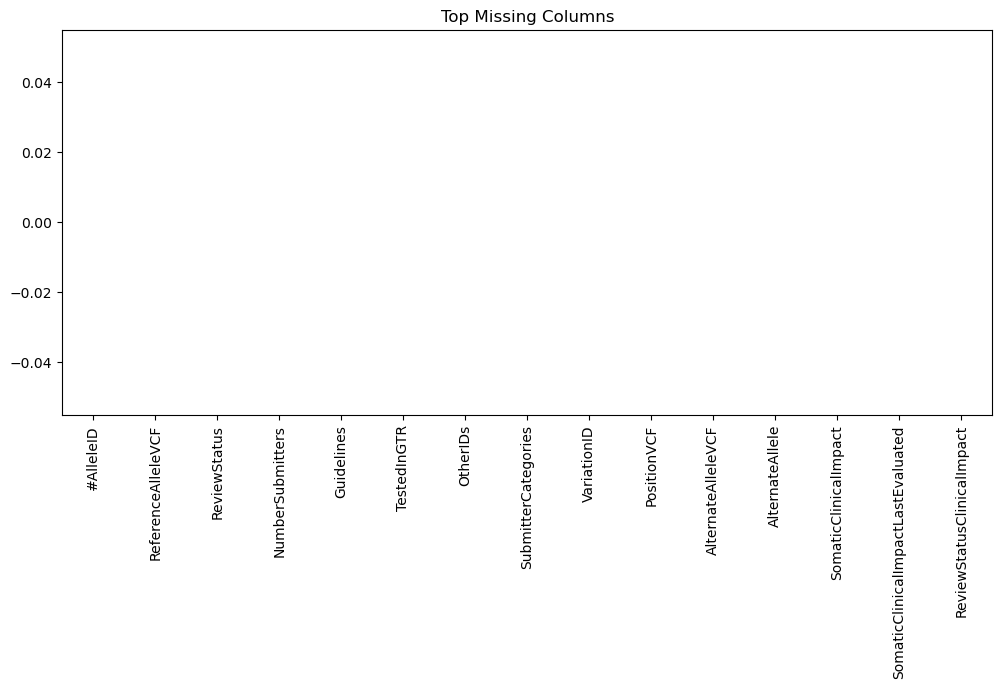

In [25]:
import matplotlib.pyplot as plt

missing.head(15).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title(
    "Top Missing Columns"
)

plt.show()

###  Key Genomic Fields

In [27]:
important_cols = [
    "#AlleleID",
    "GeneSymbol",
    "ClinicalSignificance",
    "Chromosome",
    "PhenotypeList",
    "ReviewStatus"
]

df[important_cols].head()

,#AlleleID,GeneSymbol,ClinicalSignificance,Chromosome,PhenotypeList,ReviewStatus
0,15041,AP5Z1,Pathogenic/Likely pathogenic,7,Hereditary spastic paraplegia 48|Macular dystr...,"criteria provided, multiple submitters, no con..."
1,15041,AP5Z1,Pathogenic/Likely pathogenic,7,Hereditary spastic paraplegia 48|Macular dystr...,"criteria provided, multiple submitters, no con..."
2,15042,AP5Z1,Pathogenic,7,Hereditary spastic paraplegia 48,no assertion criteria provided
3,15042,AP5Z1,Pathogenic,7,Hereditary spastic paraplegia 48,no assertion criteria provided
4,15043,ZNF592,Uncertain significance,15,Galloway-Mowat syndrome 1,no assertion criteria provided


### Clinical Significance Analysis

In [28]:
(
    df["ClinicalSignificance"]
    .value_counts()
    .head(15)
)

ClinicalSignificance
Pathogenic                                      25591
Pathogenic/Likely pathogenic                     5968
Conflicting classifications of pathogenicity     4472
Uncertain significance                           3492
Likely pathogenic                                3000
Benign                                           2251
Benign/Likely benign                             1328
other                                             950
not provided                                      788
Likely benign                                     508
risk factor                                       382
no classification for the single variant          221
Affects                                           165
Pathogenic; other                                 142
drug response                                     115
Name: count, dtype: int64

<Axes: xlabel='ClinicalSignificance'>

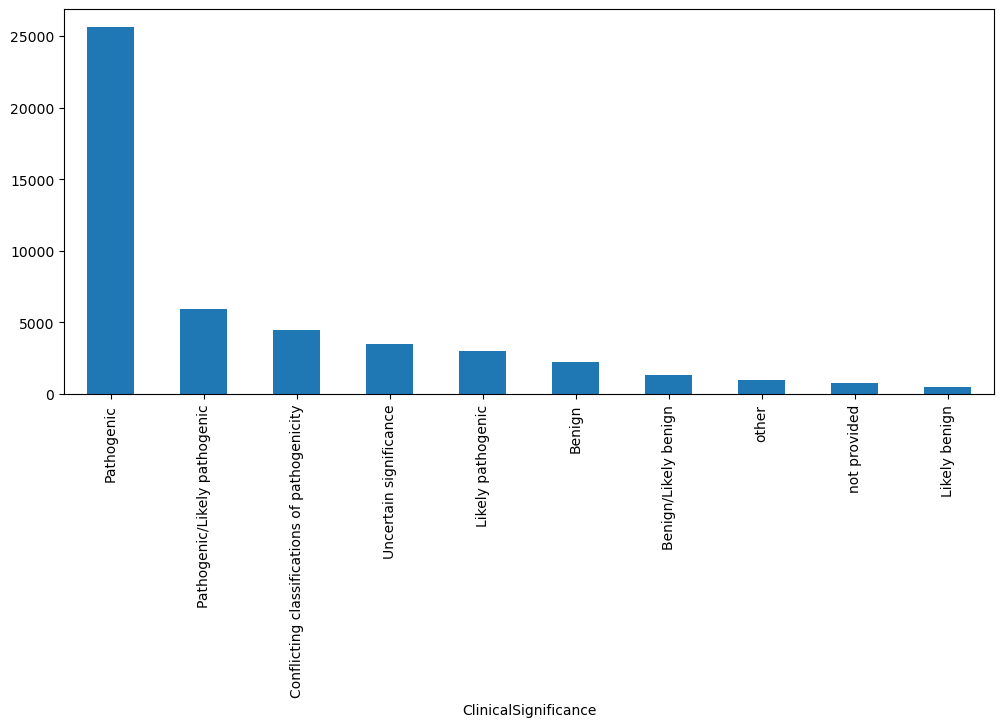

In [29]:
(
    df["ClinicalSignificance"]
    .value_counts()
    .head(10)
    .plot(
        kind="bar",
        figsize=(12,5)
    )
)

### Gene Frequency Analysis

In [30]:
(
    df["GeneSymbol"]
    .value_counts()
    .head(20)
)

GeneSymbol
BRCA2      1176
HBB        1071
BRCA1       659
COL4A5      493
F8          486
CFTR        446
HBA1        381
GALT        344
FBN1        324
RET         281
PTPN11      260
LRRK2       256
GCK         252
GNPTAB      247
BTD         238
COL1A1      202
SPG11       198
ASPM        196
SLC22A5     192
BRAF        190
Name: count, dtype: int64

###  Chromosome Analysis

In [31]:
(
    df["Chromosome"]
    .value_counts()
)

Chromosome
X     4652
11    4242
1     3765
17    3182
3     3001
2     2942
12    2701
7     2549
16    2174
13    1966
19    1916
10    1906
5     1881
9     1842
15    1718
6     1469
4     1460
8     1303
14    1288
20    1019
22     821
18     727
na     537
21     467
MT     392
Y       80
Name: count, dtype: int64

### Disease Exploration

In [32]:
df["PhenotypeList"] \
    .dropna() \
    .head(20)

0     Hereditary spastic paraplegia 48|Macular dystr...
1     Hereditary spastic paraplegia 48|Macular dystr...
2                      Hereditary spastic paraplegia 48
3                      Hereditary spastic paraplegia 48
4                             Galloway-Mowat syndrome 1
5                             Galloway-Mowat syndrome 1
6     Mitochondrial complex I deficiency, nuclear ty...
7     Mitochondrial complex I deficiency, nuclear ty...
8     Mitochondrial complex I deficiency, nuclear ty...
9     Mitochondrial complex I deficiency, nuclear ty...
10    not provided|Inborn genetic diseases|Mitochond...
11    not provided|Inborn genetic diseases|Mitochond...
12    Hemochromatosis type 1|not provided|Hereditary...
13    Hemochromatosis type 1|not provided|Hereditary...
14    Hemochromatosis type 1|not provided|Hereditary...
15    Hemochromatosis type 1|not provided|Hereditary...
16    Hemochromatosis type 1|Hereditary hemochromato...
17    Hemochromatosis type 1|Hereditary hemochro

Observation:

A single genomic variant may map to multiple diseases.

This relationship will later be transformed into:

Gene → Variant → Disease

network structures using Spark.

## Review Status Analysis

In [33]:
(
    df["ReviewStatus"]
    .value_counts()
)

ReviewStatus
criteria provided, multiple submitters, no conflicts    16962
no assertion criteria provided                          16458
criteria provided, single submitter                      7456
criteria provided, conflicting classifications           4344
reviewed by expert panel                                 3631
no classification provided                                788
no classification for the single variant                  221
practice guideline                                         66
no classifications from unflagged records                  44
-                                                          30
Name: count, dtype: int64

### Curated Schema Definition

In [35]:
curated_columns = [
    "#AlleleID",
    "GeneSymbol",
    "ClinicalSignificance",
    "Chromosome",
    "PhenotypeList",
    "ReviewStatus"
]

df[curated_columns].head()

,#AlleleID,GeneSymbol,ClinicalSignificance,Chromosome,PhenotypeList,ReviewStatus
0,15041,AP5Z1,Pathogenic/Likely pathogenic,7,Hereditary spastic paraplegia 48|Macular dystr...,"criteria provided, multiple submitters, no con..."
1,15041,AP5Z1,Pathogenic/Likely pathogenic,7,Hereditary spastic paraplegia 48|Macular dystr...,"criteria provided, multiple submitters, no con..."
2,15042,AP5Z1,Pathogenic,7,Hereditary spastic paraplegia 48,no assertion criteria provided
3,15042,AP5Z1,Pathogenic,7,Hereditary spastic paraplegia 48,no assertion criteria provided
4,15043,ZNF592,Uncertain significance,15,Galloway-Mowat syndrome 1,no assertion criteria provided


## Export Curated Sample

In [36]:
df[curated_columns].to_csv(
    "../data/sample/curated_sample.csv",
    index=False
)

print(
    "Curated sample exported"
)

Curated sample exported


# Conclusions

## Dataset Acquired

✓ Downloaded ClinVar variant summary data

## Development Dataset Created

✓ Generated 50,000-row sample for local testing

## Key Features Identified

- GeneSymbol
- ClinicalSignificance
- Chromosome
- PhenotypeList
- ReviewStatus

